In [ ]:
mean =0 , std variance =1

# Deep Neural Networks and Gradient Problems

## 1. Vanishing and Exploding Gradients

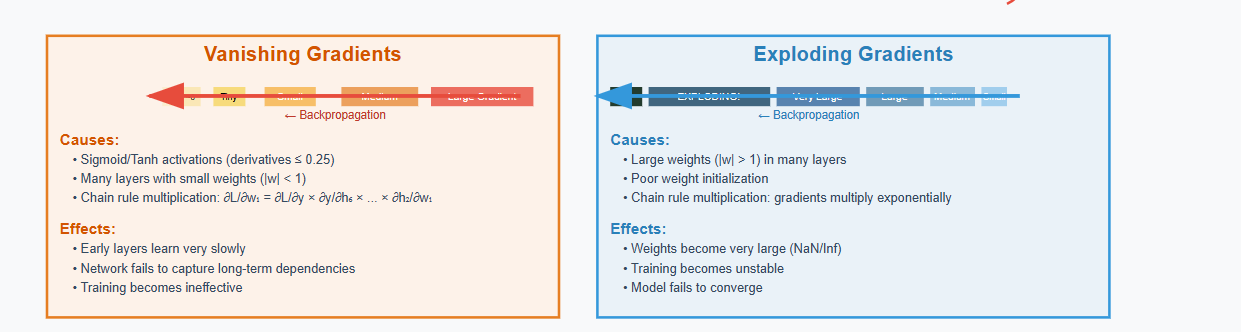



When training deep neural networks with many layers, gradients are propagated backward from the output layer to the input layer. During this process, gradients can:

- **Vanishing Gradient**: Become very small, causing the weights in early layers to update very slowly or not at all. The model fails to learn.
- **Exploding Gradient**: Become very large, causing unstable weight updates and possibly NaN losses.

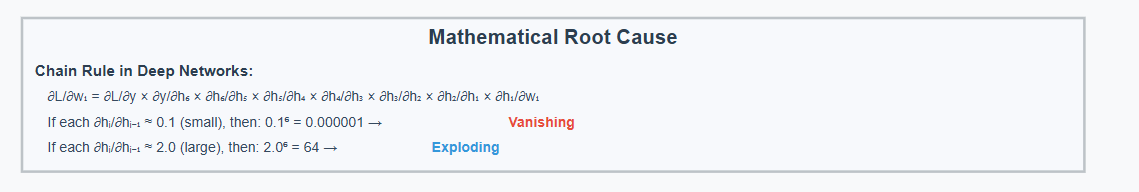

### Why This Happens:
- Each layer computes a gradient and passes it backward.
- If each gradient is < 1, multiplying many of them causes an exponentially smaller number.
- If each gradient is > 1, multiplying many leads to large explosions.

### Effects:
- **Vanishing Gradients**: Common with sigmoid/tanh activation.
- **Exploding Gradients**: Common in unnormalized networks.

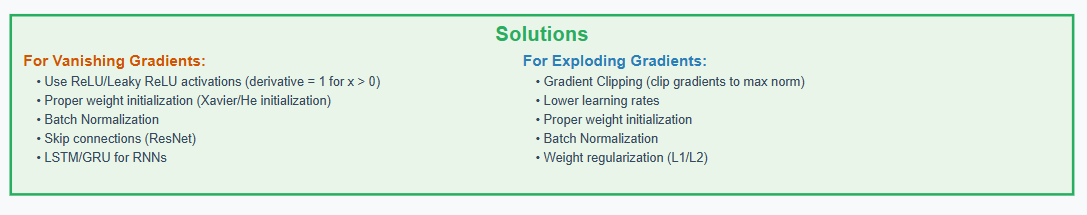
---

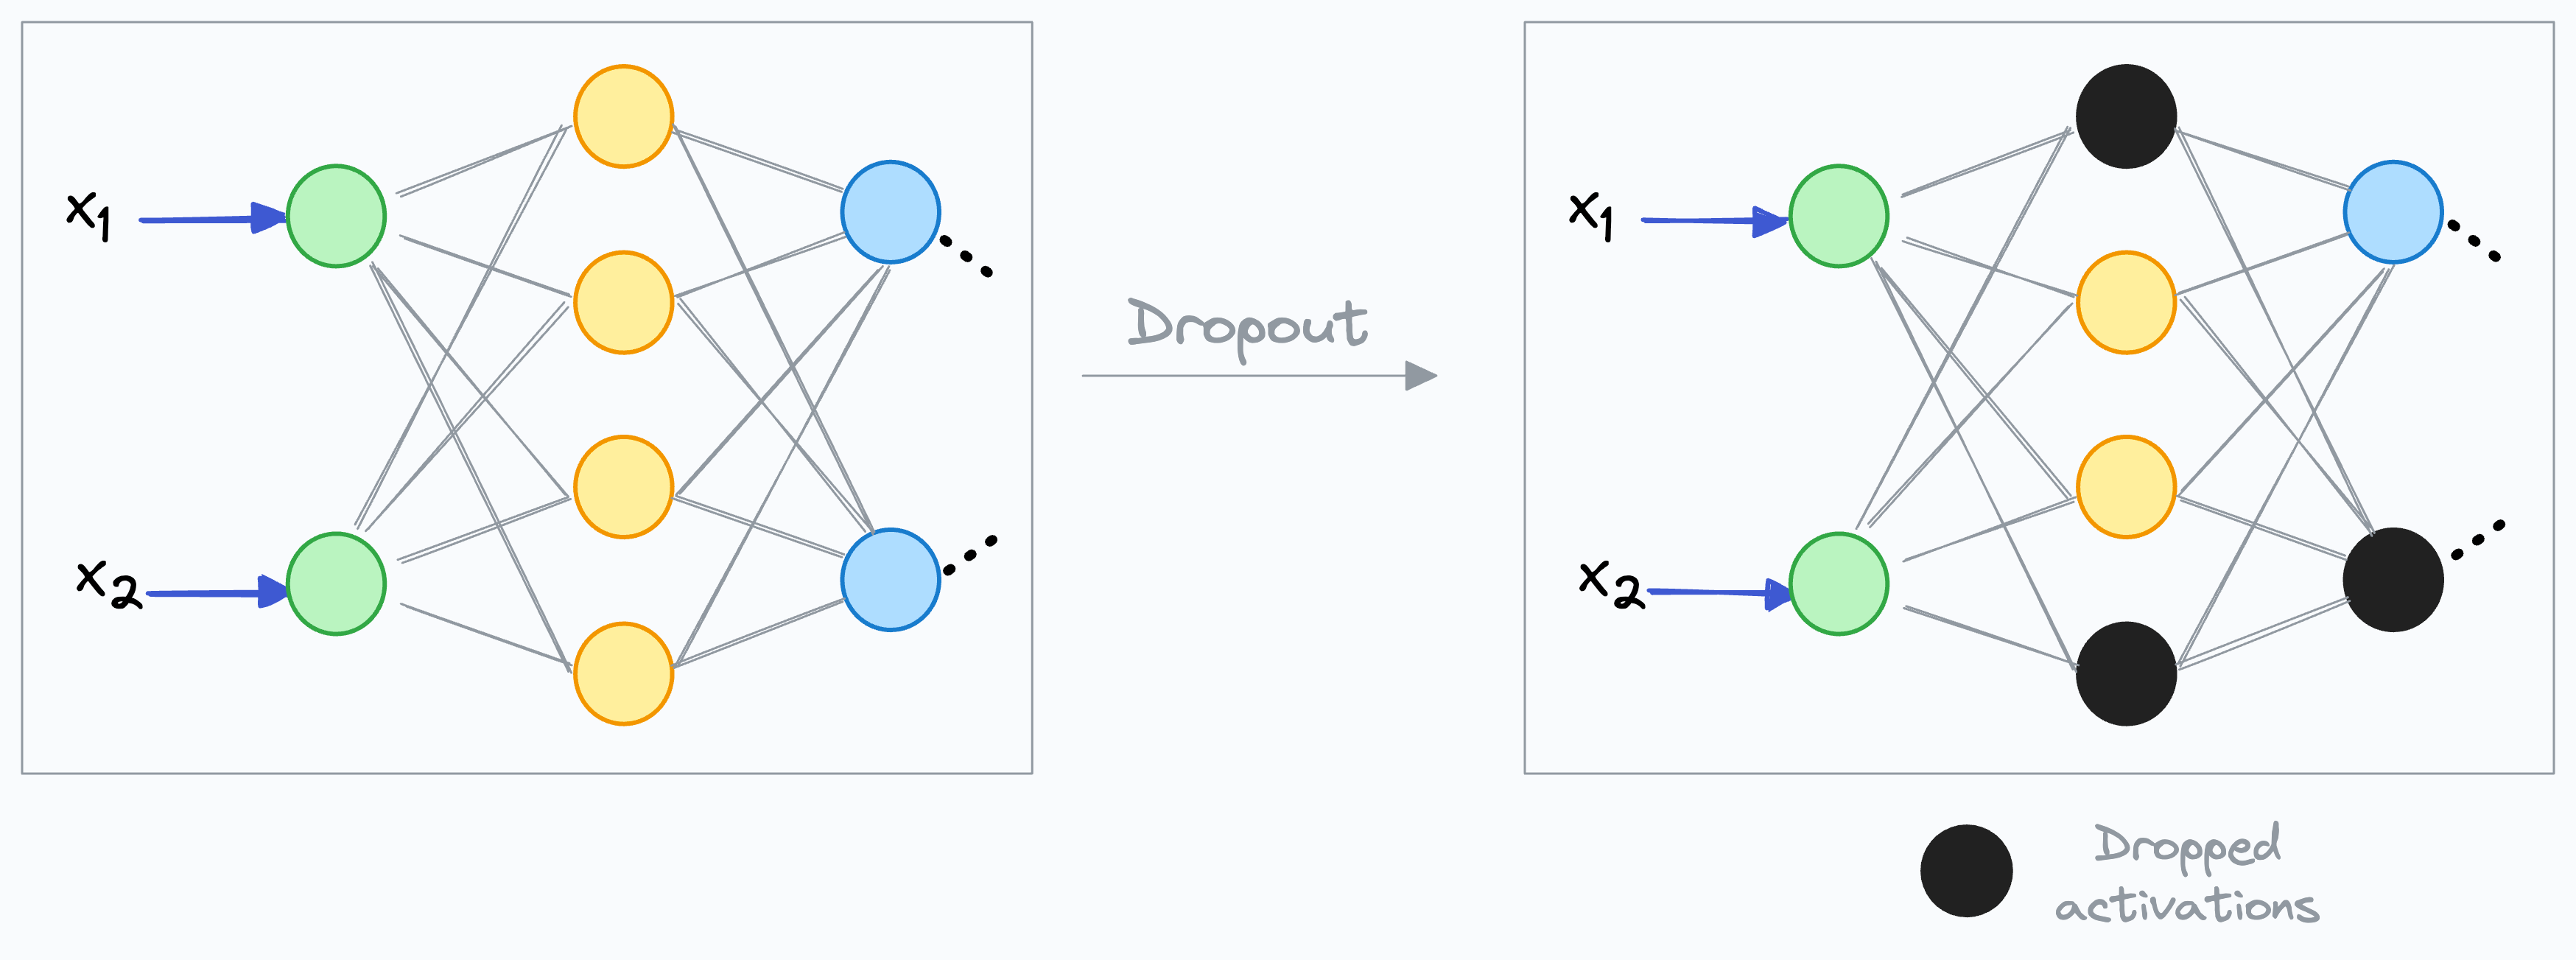

## 2. Role of Activation Functions
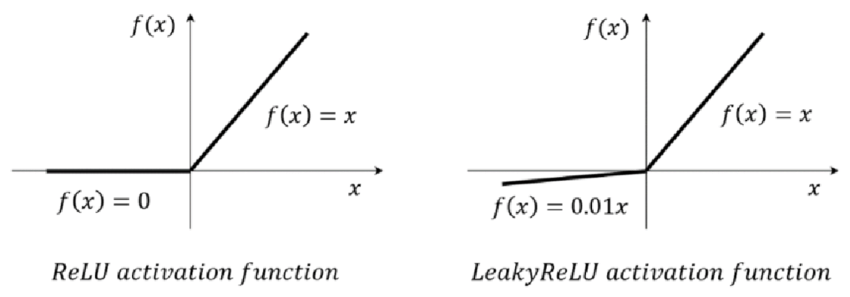
- Sigmoid and tanh squash outputs to a small range (e.g., 0–1 or -1–1), causing small derivatives.
- **ReLU** is preferred as it does not squash gradients (except at zero).
- **Leaky ReLU** improves on ReLU by allowing a small gradient when the input is negative, preventing "dead neurons."

### 🔍 Leaky ReLU
- Formula: \( f(x) = x \) if \( x > 0 \), else \( \alpha x \) (e.g., \( \alpha = 0.01 \))
- Helps maintain gradient flow for negative inputs

---

## 3. Why Normalization is Needed
- As inputs flow through layers, their distributions shift.
- This shift is called **Internal Covariate Shift**.
- Normalization stabilizes the learning process and helps gradients flow better.

---

## 4. Batch Normalization

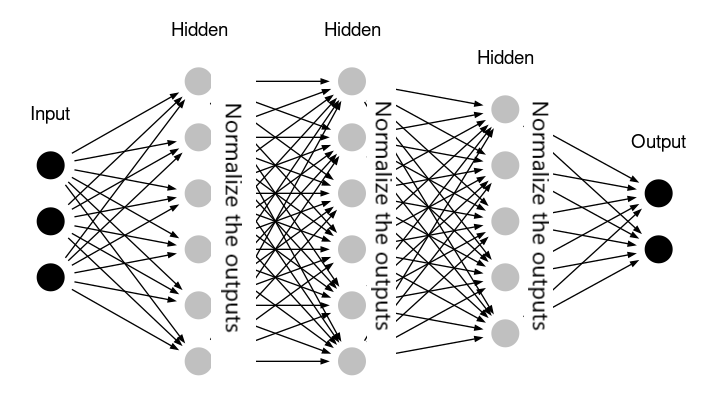

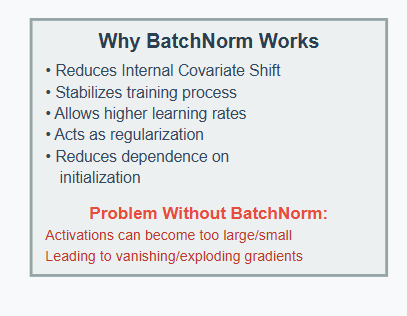

Batch Normalization is a technique that:
- Normalizes the output of a layer across the mini-batch
- Applies a scale and shift (learnable parameters)


### Benefits:
- Faster convergence
- Allows higher learning rates
- Acts as a regularizer

---

# 🔁 Practical Example: Fashion MNIST Dataset with Simple NN + BatchNorm + LeakyReLU (TensorFlow)


DATASET : https://www.kaggle.com/datasets/zalando-research/fashionmnist

In [ ]:
# Install and import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
# Load and preprocess Fashion MNIST data
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the data to [-1, 1] range
x_train = (x_train / 255.0 - 0.5) * 2
x_test = (x_test / 255.0 - 0.5) * 2

# Flatten the 28x28 images to 784-dimensional vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Normalize the data to [-1, 1] range
# Step-by-step:
# 1. x / 255.0 → scales from [0, 255] to [0, 1]
# 2. - 0.5     → shifts range from [0, 1] to [-0.5, 0.5]
# 3. * 2       → expands to [-1, 1]
# This normalization helps improve gradient flow and model convergence.
x_train = (x_train / 255.0 - 0.5) * 2
x_test = (x_test / 255.0 - 0.5) * 2


In [ ]:
x_train.shape

(60000, 784)

In [ ]:
x_train.value_counts()

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [ ]:
#check unique value of y_train
import numpy as np

# Count unique values and their counts in y_train
unique_values, counts = np.unique(y_train, return_counts=True)

# Print the unique values and their counts
for value, count in zip(unique_values, counts):
    print(f"Value: {value}, Count: {count}")
print(len(y_train))


Value: 0, Count: 6000
Value: 1, Count: 6000
Value: 2, Count: 6000
Value: 3, Count: 6000
Value: 4, Count: 6000
Value: 5, Count: 6000
Value: 6, Count: 6000
Value: 7, Count: 6000
Value: 8, Count: 6000
Value: 9, Count: 6000
60000


---

## 🧠 Detailed Explanation: Model Architecture & Building (TensorFlow)

### Input Layer
- Accepts 784-dimensional vectors (flattened 28x28 pixel grayscale images)
- Shape: `(784,)`

### Dense Layer 1
- Fully connected layer with 128 neurons
- Performs weighted sum and bias on input features

### Batch Normalization 1
- Normalizes the output of the first dense layer
- Helps reduce internal covariate shift

### Activation: Leaky ReLU 1
- Applies non-linearity
- Allows small gradients even for negative inputs

### Dense Layer 2
- Fully connected layer with 64 neurons

### Batch Normalization 2
- Normalizes the second dense layer's output

### Activation: Leaky ReLU 2
- Same benefits as above

### Output Layer
- Fully connected layer with 10 units (one per class)
- `softmax` activation outputs a probability distribution

### Optimizer
- Adam (adaptive learning rate optimization)

### Loss Function
- Sparse Categorical Crossentropy (suitable for integer-labeled classification)

### Metrics
- Accuracy is tracked during training and evaluation

---

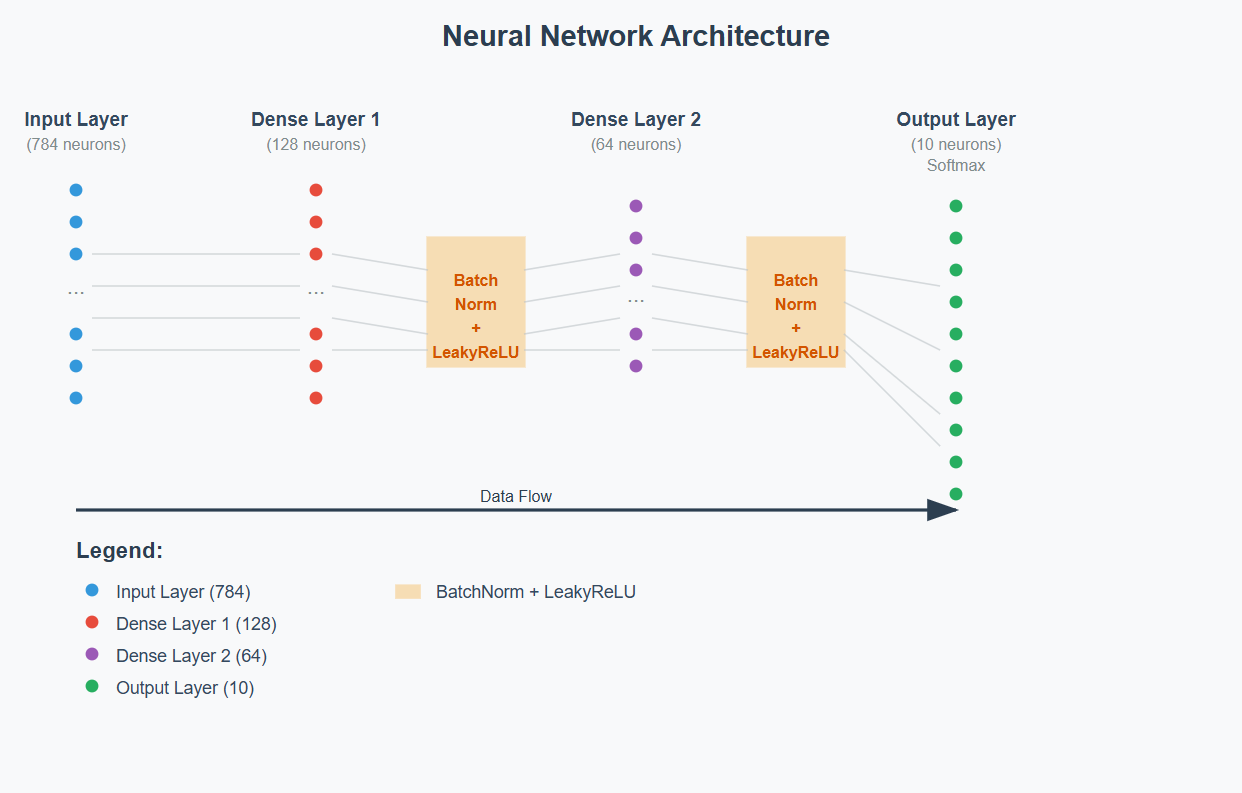

In [ ]:
# Build a simple neural network with Batch Normalization and LeakyReLU
model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128),
    layers.BatchNormalization(),  # Normalize outputs of dense layer
    layers.LeakyReLU(alpha=0.01),  # Use LeakyReLU instead of standard ReLU
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.01),
    layers.Dense(10, activation='softmax')
])

# Explanation:
# - Dense layers perform linear transformations
# - BatchNormalization stabilizes outputs before activation
# - LeakyReLU prevents dead neurons and improves gradient flow

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


## Why Do We Separate Dense, BatchNormalization, and Activation Layers?

In some previous examples, you might have seen:

layers.Dense(784, activation='relu')

This means the Dense layer applies both a linear transformation and activation at once.

However, when using **Batch Normalization**, the recommended pattern is:

layers.Dense(128),               # Linear transformation only (no activation here)  
layers.BatchNormalization(),     # Normalize outputs of Dense layer before activation  
layers.LeakyReLU(alpha=0.01),    # Apply activation after normalization

### Why?

- Batch Normalization normalizes the output of the **linear layer before the activation**.  
- If activation is inside Dense, BatchNorm would normalize **after activation**, which is not ideal.  
- Some activations like LeakyReLU are separate layers and cannot be passed inside Dense.  
- Separating these layers gives more control and improves training stability.

### Summary:

| Method                               | Pros                              | Cons                         |
|------------------------------------|----------------------------------|------------------------------|
| Dense with activation               | Simple and concise                | Can’t use BatchNorm before activation |
| Separate Dense + BatchNorm + Activation | Correct order and more flexible | Slightly more verbose code    |

### Best Practice:

When using Batch Normalization, **don’t pass activation inside Dense**. Instead, use:

layers.Dense(...)  
layers.BatchNormalization()  
layers.ActivationFunction()  # e.g., LeakyReLU

This ensures BatchNorm works correctly and helps improve model training.


In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7936 - loss: 0.6221 - val_accuracy: 0.8495 - val_loss: 0.4015
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8739 - loss: 0.3528 - val_accuracy: 0.8670 - val_loss: 0.3731
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8851 - loss: 0.3086 - val_accuracy: 0.8780 - val_loss: 0.3348
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8978 - loss: 0.2824 - val_accuracy: 0.8655 - val_loss: 0.3649
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8996 - loss: 0.2698 - val_accuracy: 0.8705 - val_loss: 0.3548
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9089 - loss: 0.2437 - val_accuracy: 0.8825 - val_loss: 0.3281
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9129 - loss: 0.2315 - val_accuracy: 0.8855 - val_loss: 0.3148
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9179 - loss: 0.2186 - val_accuracy: 0

In [ ]:
# Evaluate the model
loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8846 - loss: 0.3363
Test Accuracy: 88.67%


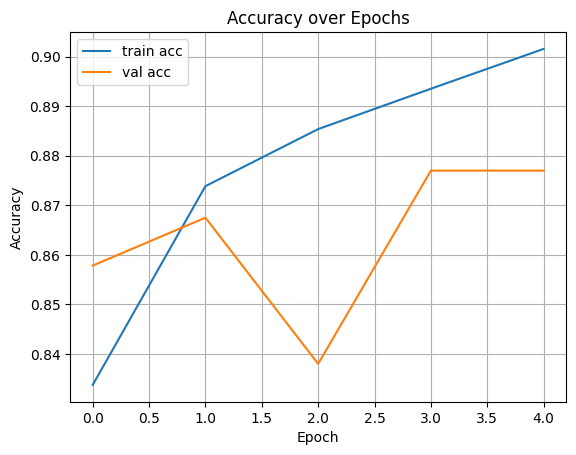

In [ ]:
# Plot training history
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Make a prediction on a single test data point
# Select the first image from the test set
single_image = x_test[0]
single_image_label = y_test[0]

# The model expects a batch of inputs, so we need to add a batch dimension
single_image = single_image.reshape(1, 784)

# Make the prediction
predictions = model.predict(single_image)

print(predictions)

# Get the predicted class (the one with the highest probability)
predicted_class = np.argmax(predictions[0])

print(f"True label: {single_image_label}")
print(f"Predicted class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[7.7100020e-07 6.4648091e-08 4.7163437e-07 8.8491312e-08 7.9056655e-08
  9.5765048e-04 2.2493627e-07 2.5101561e-02 7.5033372e-06 9.7393155e-01]]
True label: 9
Predicted class: 9
